1.Introduction
This report presents an exploratory data analysis (EDA) of the Titanic passenger dataset. The goal of EDA is to understand the structure, quality, and underlying patterns in a dataset before drawing conclusions or building models on top of it. Three specific questions were formed in advance and then investigated using summary statistics, grouped comparisons, and statistical hypothesis testing.

2. Questions Asked Before Analysis

●	Did passengers under 18 years old survive at a higher rate than passengers 18 and older?
●	Who survived more — male or female passengers?
●	Did 1st class passengers survive at a higher rate than 3rd class passengers?


In [3]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

3.1 Missing Values
Checking for missing data is a required step before trusting any pattern found later — columns with heavy missingness can bias or invalidate comparisons.

Column	       Missing Count	% Missing (of 891)
Age	                177	            ~19.9%
Cabin	            687	            ~77.1%
Embarked	         2	             ~0.2%
All other columns    0	              0%


Age is missing for about 20% of passengers, meaning the age-based comparison in this report is based only on the ~714 passengers with a known age. Cabin is missing for over 77% of records and was excluded from analysis. Embarked has only 2 missing values and does not meaningfully affect the results.


4. Question 1: Male vs. Female Survival

In [5]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

About 74.2% of female passengers survived compared to only 18.9% of male passengers — roughly a 4x difference. This is consistent with a “women and children first” evacuation priority during the sinking.

<Axes: xlabel='Sex', ylabel='Survived'>

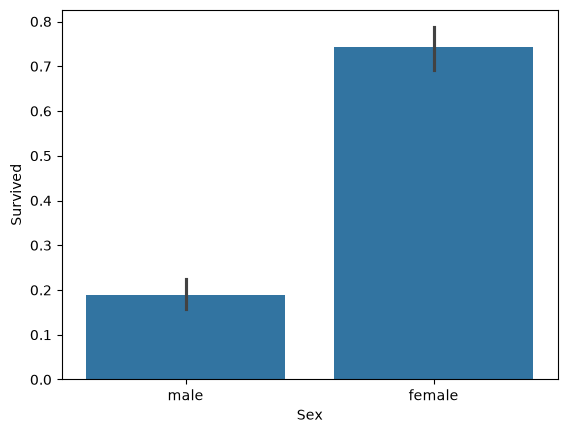

In [6]:
import seaborn as sns
sns.barplot(x="Sex" , y="Survived",data=df)

5. Question 2: 1st Class vs. 3rd Class Survival

In [7]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Survival rate decreases steadily from 1st class (63.0%) to 2nd class (47.3%) to 3rd class (24.2%). This suggests that ticket class — likely tied to cabin location and access to lifeboats — had a substantial effect on survival odds.

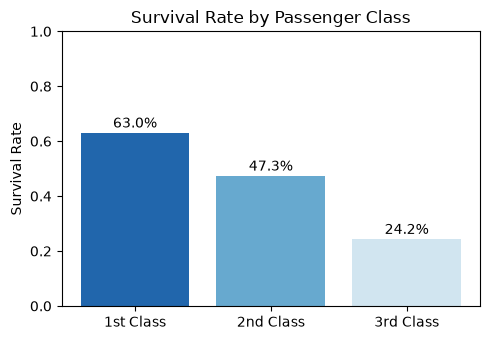

In [9]:
import matplotlib.pyplot as plt
survival_by_class = df.groupby("Pclass")["Survived"].mean()
labels = ["1st Class", "2nd Class", "3rd Class"]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, survival_by_class.values, color=['#2166ac', '#67a9cf', '#d1e5f0'])
ax.set_ylabel("Survival Rate")
ax.set_title("Survival Rate by Passenger Class")
ax.set_ylim(0, 1)
for b, v in zip(bars, survival_by_class.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v*100:.1f}%", ha="center")
plt.tight_layout()
plt.savefig("chart_class.png")
plt.show()

6. Question 3: Under 18 vs. 18+ Survival

In [14]:
df["under_18"] = df["Age"] < 18
df.groupby("under_18")["Survived"].mean()

under_18
False    0.361183
True     0.539823
Name: Survived, dtype: float64

Among passengers with a known age, 53.9% of those under 18 survived compared to 36.1% of those 18 and older. This supports the hypothesis that children were prioritized during evacuation, although the gap is smaller than the gap observed for sex or class.

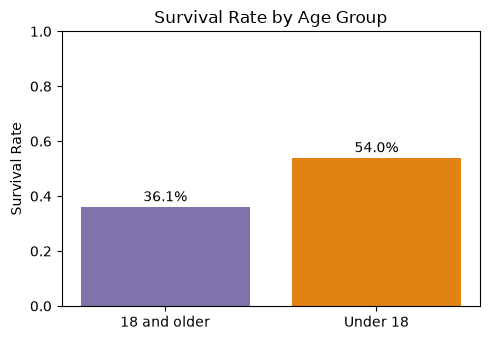

In [10]:
df["under_18"] = df["Age"] < 18
survival_by_age = df.groupby("under_18")["Survived"].mean()
labels = ["18 and older", "Under 18"]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, survival_by_age.values, color=['#8073ac', '#e08214'])
ax.set_ylabel("Survival Rate")
ax.set_title("Survival Rate by Age Group")
ax.set_ylim(0, 1)
for b, v in zip(bars, survival_by_age.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v*100:.1f}%", ha="center")
plt.tight_layout()
plt.savefig("chart_age.png")
plt.show()

7. Hypothesis Testing (Chi-Square Tests):

Visual/grouped differences alone don't confirm a pattern is real rather than random chance. A chi-square test of independence was run for each variable against Survived. A p-value below 0.05 indicates the relationship is statistically significant.


In [16]:
from scipy import stats

table = pd.crosstab(df["Sex"], df["Survived"])
chi2, p, dof, expected = stats.chi2_contingency(table)
print("p-value:", p)

p-value: 1.1973570627755645e-58


In [17]:
table_class = pd.crosstab(df["Pclass"], df["Survived"])
chi2, p, dof, expected = stats.chi2_contingency(table_class)
print("p-value:", p)

p-value: 4.549251711298793e-23


In [18]:
table_age = pd.crosstab(df["under_18"], df["Survived"])
chi2, p, dof, expected = stats.chi2_contingency(table_age)
print("p-value:", p)

p-value: 0.00039219174140767127


8. Data Issues to Address Before Further Analysis
●	Age: ~20% missing — requires imputation (e.g., median age, or median grouped by Sex/Pclass) before use in modeling.
●	Cabin: ~77% missing — not usable directly; could be converted into a binary “has_cabin” flag instead of being dropped entirely.
●	Embarked: 2 missing values — safe to fill with the most common port (mode).
●	Fare: right-skewed with some extreme outliers — worth checking individually and possibly log-transforming for modeling.


9. Conclusion
All three initial questions were confirmed by the data and validated statistically. Sex was the strongest predictor of survival, followed by passenger class, and then age group. These findings align with the historical account of a “women and children first” evacuation policy that was also influenced by class-based access to lifeboats. Before this dataset could be used for predictive modeling, the missing values in Age, Cabin, and Embarked identified in Section 3.1 and Section 8 would need to be addressed.
